In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
result_dir = 'results'
# result_summary_df = pd.DataFrame(columns=['fu_measure', 'fu_pred', 'percent_error', 
#                                           'wind_speed_mps', 'wind_speed_rel_mps', 'mass_cv', 'air_temp', 
#                                           'air_pres', 'weather_desc', 'travel_dist'])
stats_per100km_summary_df = pd.DataFrame(columns=['distance_km', 'fu_measure_per100km', 'fu_pred_per100km', 'fu_pred_cycle_per100km', 
                                         'fu_pred_error_percent_per100km','fu_pred_cycle_error_percent_per100km', 'avg_wind_speed_mps'])

# 遍历指定目录下的所有文件夹
for folder in os.listdir(result_dir):
    folder_path = os.path.join(result_dir, folder)
    if os.path.isdir(folder_path):
        # 读取文件夹下的fuel_use_stats.csv
        stats_file_path = os.path.join(folder_path, 'fuel_use_stats.csv')
        df = pd.read_csv(stats_file_path)
        # 找到最后一行所有数据都非NaN的行
        for i in range(len(df) - 1, -1, -1):
            if df.iloc[i].notna().all():
                last_row = df.iloc[i]
                break
        else:
            continue  # 如果没有找到全非NaN的行则跳过
        stats_per100km_summary_df.loc[len(stats_per100km_summary_df)] = {
            'distance_km': last_row['Distance (km)'],
            'fu_measure_per100km': last_row['Measurement (L)'] / last_row['Distance (km)'] * 100,
            'fu_pred_per100km': last_row['Simulation (L)'] / last_row['Distance (km)'] * 100,
            'fu_pred_cycle_per100km': last_row['Pred. & Simulation (L)'] / last_row['Distance (km)'] * 100,
            'fu_pred_error_percent_per100km': last_row['Simulation Error (%)'],
            'fu_pred_cycle_error_percent_per100km': last_row['Pred. & Simulation Error (%)'],
            'avg_wind_speed_mps': last_row['Avg Wind Speed (m/s)']
        }

stats_per100km_summary_df 

,distance_km,fu_measure_per100km,fu_pred_per100km,fu_pred_cycle_per100km,fu_pred_error_percent_per100km,fu_pred_cycle_error_percent_per100km,avg_wind_speed_mps
0,114.21,32.913055,32.484021,32.860520,-1.28,-0.16,4.71
1,59.25,33.181435,30.160338,27.510549,-9.08,-17.06,5.21
2,67.35,33.199703,32.011878,28.507795,-3.60,-14.17,6.60
3,63.49,23.893527,22.507481,20.727674,-5.84,-13.25,7.64
4,70.86,40.841095,41.151566,40.008467,0.76,-2.03,6.90
5,182.60,33.384447,32.979189,29.556407,-1.20,-11.46,3.29
6,154.63,27.155145,28.577896,28.687835,5.24,5.64,1.75
7,331.23,21.462428,22.549286,21.616399,5.06,0.71,1.76
8,63.74,23.266395,21.791654,20.489489,-6.29,-11.92,1.39
9,155.36,27.188465,30.091401,28.733265,10.68,5.69,2.14


C:\Users\jh2570\AppData\Local\Temp\ipykernel_151348\521769867.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([stats_per100km_summary_df['fu_measure_per100km'],


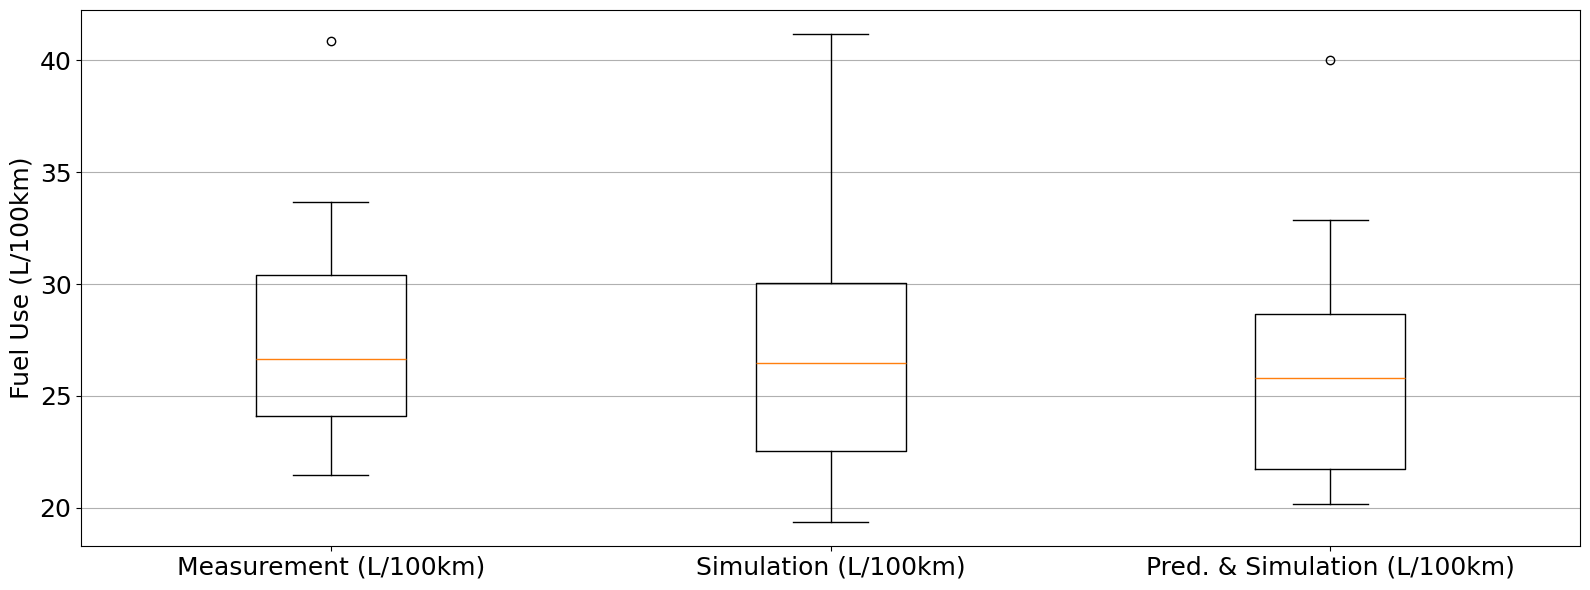

In [3]:
# 用统计图（箱线图）表示 stats_summary_df
plt.figure(figsize=(16, 6))
plt.boxplot([stats_per100km_summary_df['fu_measure_per100km'],
             stats_per100km_summary_df['fu_pred_per100km'],
            stats_per100km_summary_df['fu_pred_cycle_per100km']],
            labels=['Measurement (L/100km)', 'Simulation (L/100km)', 'Pred. & Simulation (L/100km)'])
plt.ylabel('Fuel Use (L/100km)', fontsize=18)
# plt.xlabel('Method', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('figures/fuel_use_boxplot.png', dpi=300)
plt.show()

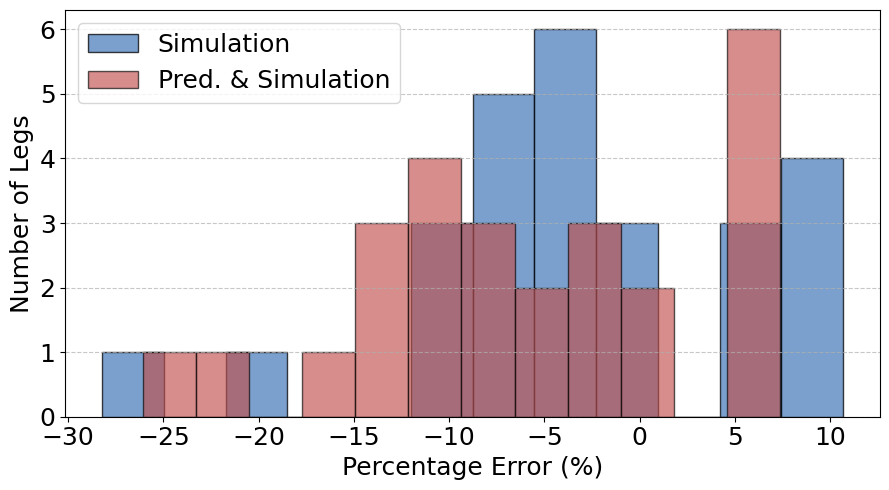

Simulation PE: -3.15%, Std: 8.88%
Pred. & Simulation PE: -6.01%, Std: 9.36%


In [4]:
plt.figure(figsize=(9, 5))
plt.hist(stats_per100km_summary_df['fu_pred_error_percent_per100km'], bins=12, alpha=0.75, label='Simulation', color='#4F81BD', edgecolor='black')
plt.hist(stats_per100km_summary_df['fu_pred_cycle_error_percent_per100km'].dropna(), bins=12, alpha=0.65, label='Pred. & Simulation', color='#C0504D', edgecolor='black')
plt.xlabel('Percentage Error (%)', fontsize=18)
plt.ylabel('Number of Legs', fontsize=18)
# plt.title('Distribution of Fuel Use Prediction Errors', fontsize=18, fontweight='bold')
plt.legend(fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('figures/PE_fuel_use_prediction_errors_distribution.png', dpi=300)
plt.show()
# 输出均值和标准差
mean_error = stats_per100km_summary_df['fu_pred_error_percent_per100km'].mean()
std_error = stats_per100km_summary_df['fu_pred_error_percent_per100km'].std()
mean_cycle_error = stats_per100km_summary_df['fu_pred_cycle_error_percent_per100km'].mean()
std_cycle_error = stats_per100km_summary_df['fu_pred_cycle_error_percent_per100km'].std()
print(f"Simulation PE: {mean_error:.2f}%, Std: {std_error:.2f}%")
print(f"Pred. & Simulation PE: {mean_cycle_error:.2f}%, Std: {std_cycle_error:.2f}%")


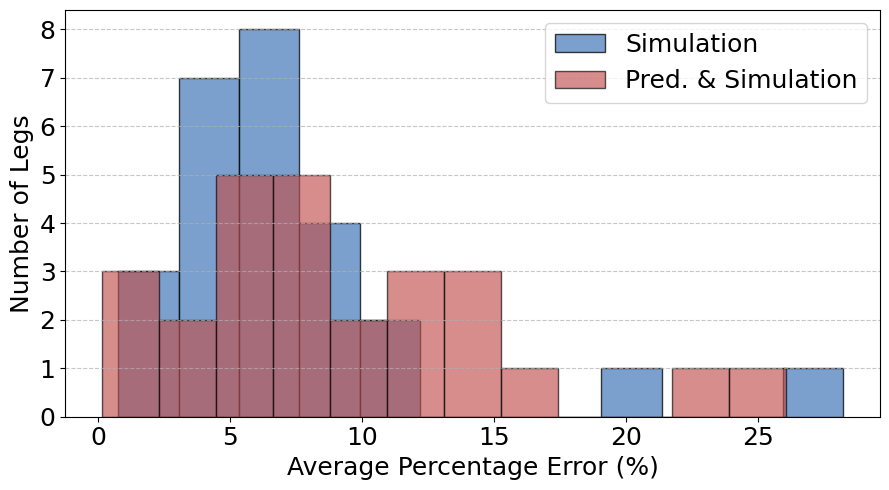

Simulation Average Percentage Error: 7.27%, Std: 5.84%
Pred. & Simulation Average Percentage Error: 9.10%, Std: 6.25%


In [5]:
plt.figure(figsize=(9, 5))
plt.hist(stats_per100km_summary_df['fu_pred_error_percent_per100km'].abs(), bins=12, alpha=0.75, label='Simulation', color='#4F81BD', edgecolor='black')
plt.hist(stats_per100km_summary_df['fu_pred_cycle_error_percent_per100km'].abs().dropna(), bins=12, alpha=0.65, label='Pred. & Simulation', color='#C0504D', edgecolor='black')
plt.xlabel('Average Percentage Error (%)', fontsize=18)
plt.ylabel('Number of Legs', fontsize=18)
# plt.title('Distribution of Fuel Use Prediction Errors', fontsize=18, fontweight='bold')
plt.legend(fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('figures/APE_fuel_use_prediction_errors_distribution.png', dpi=300)
plt.show()
# 输出均值
mean_abs_error = stats_per100km_summary_df['fu_pred_error_percent_per100km'].abs().mean()
std_abs_error = stats_per100km_summary_df['fu_pred_error_percent_per100km'].abs().std()
mean_abs_cycle_error = stats_per100km_summary_df['fu_pred_cycle_error_percent_per100km'].abs().mean()
std_abs_cycle_error = stats_per100km_summary_df['fu_pred_cycle_error_percent_per100km'].abs().std()
print(f"Simulation Average Percentage Error: {mean_abs_error:.2f}%, Std: {std_abs_error:.2f}%")
print(f"Pred. & Simulation Average Percentage Error: {mean_abs_cycle_error:.2f}%, Std: {std_abs_cycle_error:.2f}%")

In [8]:
### 计算风速小于3m/s时的平均绝对百分比误差
low_wind_df = stats_per100km_summary_df[stats_per100km_summary_df['avg_wind_speed_mps'] < 3]
low_wind_df

,distance_km,fu_measure_per100km,fu_pred_per100km,fu_pred_cycle_per100km,fu_pred_error_percent_per100km,fu_pred_cycle_error_percent_per100km,avg_wind_speed_mps
6,154.63,27.155145,28.577896,28.687835,5.24,5.64,1.75
7,331.23,21.462428,22.549286,21.616399,5.06,0.71,1.76
8,63.74,23.266395,21.791654,20.489489,-6.29,-11.92,1.39
9,155.36,27.188465,30.091401,28.733265,10.68,5.69,2.14
10,113.10,22.776304,20.557029,20.486295,-9.77,-10.05,2.09
11,152.19,26.788882,28.825810,28.766673,7.60,7.37,2.38
12,159.09,26.324722,24.891571,25.576718,-5.43,-2.83,1.25
13,156.88,25.350586,27.186384,27.148139,7.25,7.08,1.77
14,81.26,24.883091,23.160226,22.126508,-6.88,-11.07,2.96
15,112.37,21.527098,19.373498,20.459197,-9.99,-4.97,2.53


In [9]:
low_wind_df_without_outlier = low_wind_df[low_wind_df['fu_pred_cycle_error_percent_per100km'].abs() < 20]
low_wind_df_without_outlier

,distance_km,fu_measure_per100km,fu_pred_per100km,fu_pred_cycle_per100km,fu_pred_error_percent_per100km,fu_pred_cycle_error_percent_per100km,avg_wind_speed_mps
6,154.63,27.155145,28.577896,28.687835,5.24,5.64,1.75
7,331.23,21.462428,22.549286,21.616399,5.06,0.71,1.76
8,63.74,23.266395,21.791654,20.489489,-6.29,-11.92,1.39
9,155.36,27.188465,30.091401,28.733265,10.68,5.69,2.14
10,113.10,22.776304,20.557029,20.486295,-9.77,-10.05,2.09
11,152.19,26.788882,28.825810,28.766673,7.60,7.37,2.38
12,159.09,26.324722,24.891571,25.576718,-5.43,-2.83,1.25
13,156.88,25.350586,27.186384,27.148139,7.25,7.08,1.77
14,81.26,24.883091,23.160226,22.126508,-6.88,-11.07,2.96
15,112.37,21.527098,19.373498,20.459197,-9.99,-4.97,2.53


In [11]:
low_wind_df_without_outlier_mean_abs_error = low_wind_df_without_outlier['fu_pred_cycle_error_percent_per100km'].abs().mean()
low_wind_df_without_outlier_std_abs_error = low_wind_df_without_outlier['fu_pred_cycle_error_percent_per100km'].abs().std()
low_wind_df_without_outlier_mean_abs_error, low_wind_df_without_outlier_std_abs_error

(6.810909090909092, 3.3883844367056537)